<a href="https://colab.research.google.com/github/Anarzel/FUNDAI-Laboratories-Lopez/blob/main/Lab2_Search_Algorithms_Lopez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Maze Solving Using BFS, DFS, and A* Search

## Fundamentals of Artificial Intelligence

**Name:** ADRIAN F. LOPEZ
**Course:** BSCS-AI
**Section:** 2A
**Date:** 8/26/26

**GitHub URL:** https://github.com/Anarzel

## Description
This laboratory implements BFS, DFS, and A* Search to solve a maze.
The search results are visualized using matplotlib.


In [1]:
from collections import deque
import heapq
import numpy as np
import matplotlib.pyplot as plt

## Maze Class

The `Maze` class stores the grid, start position, and goal position.
The value `0` represents an open cell.
The value `1` represents a wall.

In [2]:
class Maze:
    def __init__(self, grid, start, goal):
        self.grid = grid
        self.start = start
        self.goal = goal
        self.rows = len(grid)
        self.cols = len(grid[0]) if self.rows > 0 else 0

    def inside(self, pos):
        r, c = pos
        return 0 <= r < self.rows and 0 <= c < self.cols

    def passable(self, pos):
        if not self.inside(pos):
            return False
        r, c = pos
        return self.grid[r][c] == 0

    def neighbors(self, pos):
        r, c = pos
        directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        result = []

        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            next_pos = (nr, nc)

            if self.passable(next_pos):
                result.append(next_pos)

        return result

## SearchResult Class

The `SearchResult` class stores the output of each search algorithm. It includes the algorithm name, success status, path, visited order, and parent map.


In [3]:
class SearchResult:
    def __init__(self, algorithm, success, path, visited_order, parent, root):
        self.algorithm = algorithm
        self.success = success
        self.path = path
        self.visited_order = visited_order
        self.parent = parent
        self.root = root

        self.path_set = set(path)
        self.visited_set = set(visited_order)

    @property
    def path_length(self):
        return len(self.path)

    @property
    def nodes_expanded(self):
        return len(self.visited_order)

    def summary(self):
        print(f"Algorithm: {self.algorithm}")
        print(f"Success: {self.success}")
        print(f"Path Length: {self.path_length}")
        print(f"Nodes expanded/popped: {self.nodes_expanded}")
        print(f"Path: {self.path}")
        print("-" * 50)

## SearchSolver Class

The `SearchSolver` class contains the implementaion of BFS, DFS, and A* Search.

In [4]:
class SearchSolver:
    def __init__(self, maze):
        self.maze = maze

    def _reconstruct_path(self, parent, goal):
        path = []
        current = goal

        while current is not None:
            path.append(current)
            current = parent[current]

        path.reverse()
        return path

    def _heuristic(self, a, b):
        return abs(a[0] - b[0]) + abs(a[1] - b[1])

    def bfs(self):
        start = self.maze.start
        goal = self.maze.goal

        if not self.maze.passable(start) or not self.maze.passable(goal):
            return SearchResult("BFS", False, [], [], {start: None}, start)

        frontier = deque([start])
        visited = {start}
        parent = {start: None}
        visited_order = []
        success = False

        while frontier:
            current = frontier.popleft()
            visited_order.append(current)

            if current == goal:
                success = True
                break

            for neighbor in self.maze.neighbors(current):
                if neighbor not in visited:
                    visited.add(neighbor)
                    parent[neighbor] = current
                    frontier.append(neighbor)


        path = self._reconstruct_path(parent, goal) if success else []

        return SearchResult(
            algorithm="BFS",
            success=success,
            path=path,
            visited_order=visited_order,
            parent=parent,
            root=start
        )

    def dfs(self):
        start = self.maze.start
        goal = self.maze.goal

        if not self.maze.passable(start) or not self.maze.passable(goal):
              return SearchResult("DFS", False, [], [], {start: None}, start)

        frontier = [start]
        visited = {start}
        parent = {start: None}
        visited_order = []
        success = False

        while frontier:
            current = frontier.pop()
            visited_order.append(current)

            if current == goal:
                success = True
                break

            # reversed is used so that the first neighbor appears explored first
            for neighbor in reversed(self.maze.neighbors(current)):
                if neighbor not in visited:
                    visited.add(neighbor)
                    parent[neighbor] = current
                    frontier.append(neighbor)

        path = self._reconstruct_path(parent, goal) if success else []

        return SearchResult(
            algorithm="DFS",
            success=success,
            path=path,
            visited_order=visited_order,
            parent=parent,
            root=start
        )

    def astar(self):
        start = self.maze.start
        goal = self.maze.goal

        if not self.maze.passable(start) or not self.maze.passable(goal):
            return SearchResult("A* Search", False, [], [], {start: None}, start)

        counter = 0
        open_heap = []
        heapq.heappush(open_heap, (0, counter, start))

        g_score = {start: 0}
        parent = {start: None}
        visited = set()
        visited_order = []
        success = False

        while open_heap:
            f, _, current = heapq.heappop(open_heap)

            if current in visited:
                continue

            visited.add(current)
            visited_order.append(current)

            if current == goal:
                success = True
                break

            for neighbor in self.maze.neighbors(current):
                tentative_g = g_score[current] + 1

                if tentative_g < g_score.get(neighbor, float('inf')):
                    g_score[neighbor] = tentative_g
                    f_score = tentative_g + self._heuristic(neighbor, goal)

                    parent[neighbor] = current
                    counter += 1
                    heapq.heappush(open_heap, (f_score, counter, neighbor))

        path = self._reconstruct_path(parent, goal) if success else []

        return SearchResult(
            algorithm="A* Search",
            success=success,
            path=path,
            visited_order=visited_order,
            parent=parent,
            root=start
        )

## Sample Maze

The maze uses:

- `0` for open cells
- `1` for walls


In [5]:
grid = [
    [0, 0, 0, 0, 1, 0, 0],
    [1, 1, 0, 1, 1, 0, 1],
    [0, 0, 0, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0]
]

start = (0, 0)
goal = (6, 6)

maze = Maze(grid, start, goal)
solver = SearchSolver(maze)

In [6]:
bfs_result = solver.bfs()
dfs_result = solver.dfs()
astar_result = solver.astar()

In [7]:
bfs_result.summary()
dfs_result.summary()
astar_result.summary()

Algorithm: BFS
Success: True
Path Length: 17
Nodes expanded/popped: 22
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]
--------------------------------------------------
Algorithm: DFS
Success: True
Path Length: 17
Nodes expanded/popped: 17
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]
--------------------------------------------------
Algorithm: A* Search
Success: True
Path Length: 17
Nodes expanded/popped: 22
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]
--------------------------------------------------


## Visualization Using matplotlib

The visualization shows:

- Black: wall
- White: open cell
- Light blue: visited/expanded cells
- Yellow: final path
- Green: start
- Red: goal

In [8]:
def visualize_search(maze, result, title="Search Result"):
    img = np.ones((maze.rows, maze.cols, 3))

    # Draw walls
    for r in range(maze.rows):
        for c in range(maze.cols):
            if maze.grid[r][c] == 1:
                img[r, c] = (0.1, 0.1, 0.1)

    if result is not None:
        # Draw visited/expanded cells
        for r, c in result.visited_set:
            if maze.grid[r][c] == 0:
                img[r, c] = (0.75, 0.87, 1.0)

        # Draw final path
        for r, c in result.path_set:
            if maze.grid[r][c] == 0:
                img[r, c] = (1.0, 0.85, 0.3)

    # Draw start and goal
    img[maze.start] = (0.2, 0.8, 0.2)
    img[maze.goal] = (0.9, 0.2, 0.2)

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

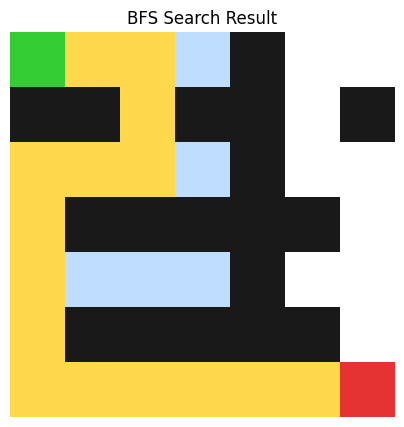

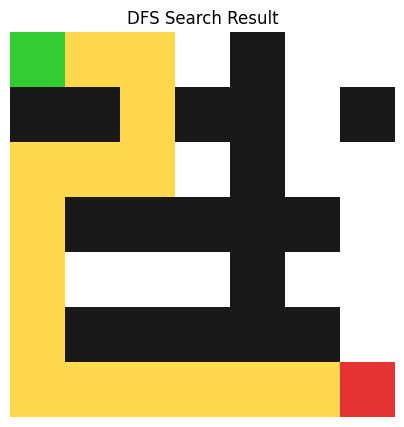

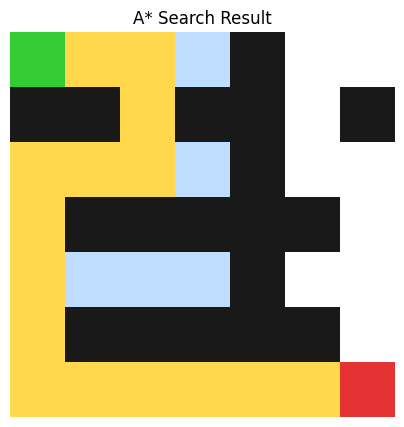

In [9]:
visualize_search(maze, bfs_result, "BFS Search Result")
visualize_search(maze, dfs_result, "DFS Search Result")
visualize_search(maze, astar_result, "A* Search Result")

## Search Tree Documentation

The search tree is generated from the parent map.
Each child node is connected to its predecessor.

In [10]:
def search_tree_text(result, max_lines=100):
    children = {}

    for child, predecessor in result.parent.items():
        if predecessor is not None:
            if predecessor not in children:
                children[predecessor] = []
            children[predecessor].append(child)

    for node in children:
        children[node].sort()

    lines = []

    def build(node, depth):
        if len(lines) >= max_lines:
            return

        lines.append(" " * depth + str(node))

        for child in children.get(node, []):
            build(child, depth + 1)

    build(result.root, 0)

    if len(lines) >= max_lines:
        lines.append("... search tree truncated for report")

    return "\n".join(lines)

In [11]:
print("BFS Search Tree")
print(search_tree_text(bfs_result, max_lines=80))

print("\nDFS Search Tree")
print(search_tree_text(dfs_result, max_lines=80))

print("\nA* Search Tree")
print(search_tree_text(astar_result, max_lines=80))

BFS Search Tree
(0, 0)
 (0, 1)
  (0, 2)
   (0, 3)
   (1, 2)
    (2, 2)
     (2, 1)
      (2, 0)
       (3, 0)
        (4, 0)
         (4, 1)
          (4, 2)
           (4, 3)
         (5, 0)
          (6, 0)
           (6, 1)
            (6, 2)
             (6, 3)
              (6, 4)
               (6, 5)
                (6, 6)
     (2, 3)

DFS Search Tree
(0, 0)
 (0, 1)
  (0, 2)
   (0, 3)
   (1, 2)
    (2, 2)
     (2, 1)
      (2, 0)
       (3, 0)
        (4, 0)
         (4, 1)
         (5, 0)
          (6, 0)
           (6, 1)
            (6, 2)
             (6, 3)
              (6, 4)
               (6, 5)
                (6, 6)
     (2, 3)

A* Search Tree
(0, 0)
 (0, 1)
  (0, 2)
   (0, 3)
   (1, 2)
    (2, 2)
     (2, 1)
      (2, 0)
       (3, 0)
        (4, 0)
         (4, 1)
          (4, 2)
           (4, 3)
         (5, 0)
          (6, 0)
           (6, 1)
            (6, 2)
             (6, 3)
              (6, 4)
               (6, 5)
                (6, 6)
     (2, 3)


In [12]:
def expansion_report(result, first_n=20):
    print(f"{result.algorithm} expansion order, first {first_n} nodes:")
    print(result.visited_order[:first_n])
    print("-" * 50)

expansion_report(bfs_result)
expansion_report(dfs_result)
expansion_report(astar_result)

BFS expansion order, first 20 nodes:
[(0, 0), (0, 1), (0, 2), (1, 2), (0, 3), (2, 2), (2, 1), (2, 3), (2, 0), (3, 0), (4, 0), (5, 0), (4, 1), (6, 0), (4, 2), (6, 1), (4, 3), (6, 2), (6, 3), (6, 4)]
--------------------------------------------------
DFS expansion order, first 20 nodes:
[(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]
--------------------------------------------------
A* Search expansion order, first 20 nodes:
[(0, 0), (0, 1), (0, 2), (1, 2), (0, 3), (2, 2), (2, 3), (2, 1), (2, 0), (3, 0), (4, 0), (5, 0), (4, 1), (6, 0), (4, 2), (6, 1), (4, 3), (6, 2), (6, 3), (6, 4)]
--------------------------------------------------


### BFS
BFS explores the maze level by level. It is useful for finding a shortest path when all move costs are equal.

### DFS
DFS explores one branch deeply before backtracking. It may find a solution quickly, but the path may not be short.

### A* Search
A* uses both actual cost from the start and estimated cost to the goal. With Manhattan distance, it is often more efficient than BFS.

## Observation
WHY ARE THEY ALL THE SAME MY VISUALIZATION ARE GIVING ME THE SAME NODES PATH THING THEY

## Guide Questions and Answers

### 1. Which algorithm found the shortest path?
**Answer:** BFS

### 2. Which algorithm expanded the fewest nodes?
**Answer:** DFS

### 3. Why is Manhattan distance suitable for this maze?
**Answer:** []

### 4. How does the parent map help reconstruct the path?
**Answer:** []

### 5. Why is repeated-state checking important?
**Answer:** []

## Reflection

### Challenges Encountered
- []

### What I Learned
- []